# ADCP Raw Data Processing

In [1]:
from mhkit import dolfyn
from mhkit.dolfyn.adp import api

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import my_functions as my

In [2]:
# Reading binary file
ds = dolfyn.read("A0524000.000")
ds


Reading file A0524000.000 ...


<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16864, range: 24, beam: 4, dir: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 135kB 2024-05-13T12:00:00 ... ...
  * range                (range) float32 96B 2.12 3.12 4.12 ... 24.12 25.12
  * beam                 (beam) int32 16B 1 2 3 4
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 1 2 3 4 ... 16861 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.534e+03 1.534e+03 ... 1.518e+03
    depth                (time) float32 67kB 0.0 0.0 0.0 0.0 ... 22.3 22.4 22.5
    pitch                (time) float32 67kB -4.2 -4.22 -4.2 ... -6.7 -6.7 -6.68
    roll                 (time) float32 67kB -0.07 -0.04 -0.04 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.017 nan ... nan nan
    amp                  (beam, range, time) uint8 2MB 55 55 55 ... 119 122 118
    corr                 (beam, range, time) uint8 2MB 70 73 70 ... 108 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 5 0 0 2 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 607kB -0.7555 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             0.24
    fs:                       0.0011363636363636363

### Removing data before deployment

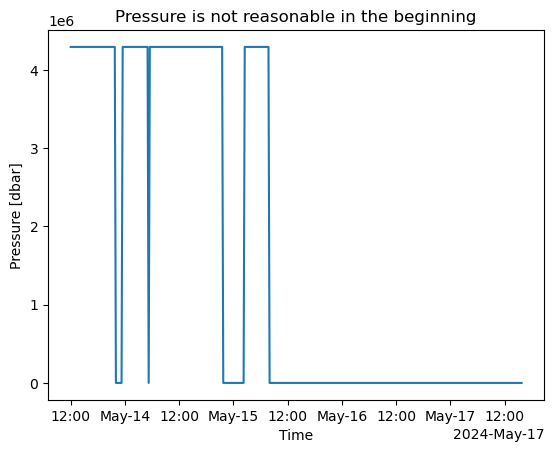

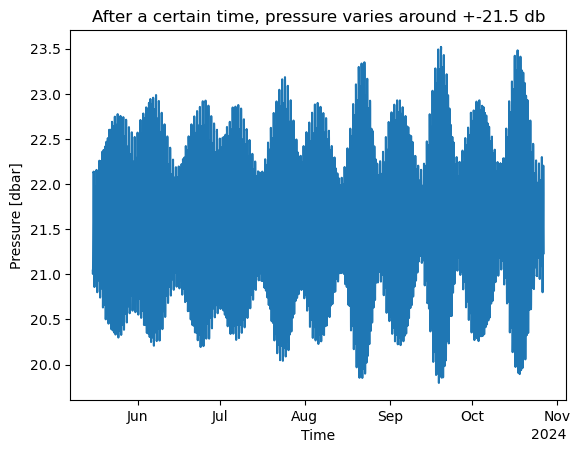

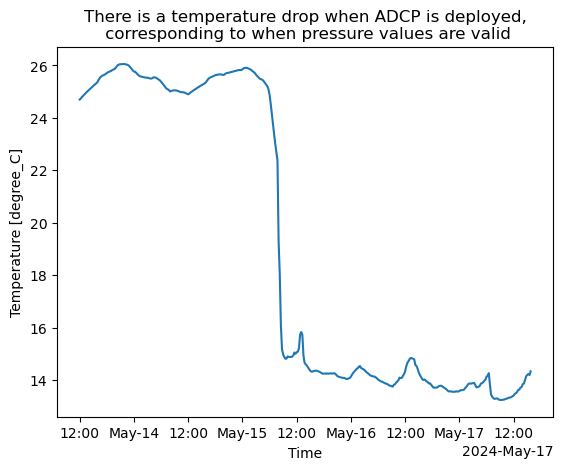

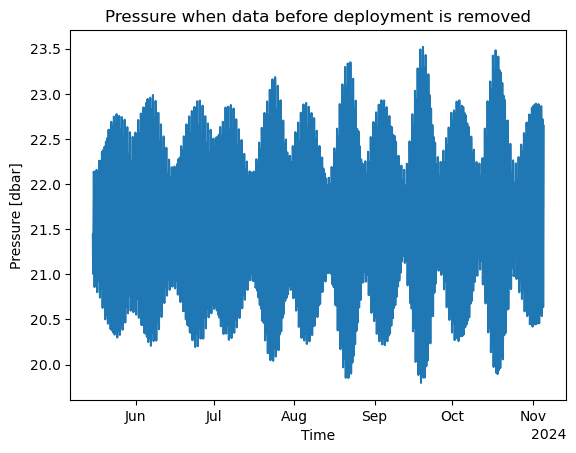

In [5]:

ds.pressure.isel(time=slice(0, 400)).plot()
plt.title('Pressure is not reasonable in the beginning')
plt.xlabel('Time')
plt.show()

ds.pressure.isel(time=slice(200,16000)).plot()
plt.title('After a certain time, pressure varies around +-21.5 db')
plt.xlabel('Time')
plt.show()

ds.temp.isel(time=slice(0, 400)).plot()
plt.title('There is a temperature drop when ADCP is deployed,\n corresponding to when pressure values are valid')
plt.xlabel('Time')
plt.show()

deployment_time = np.datetime64("2024-05-15T12:00:00") #read off from temperature plot

ds_1 = ds.sel(time=slice(deployment_time, None))

ds_1.pressure.plot()
plt.title('Pressure when data before deployment is removed')
plt.xlabel('Time')
plt.show()


### Controling of bin heights relative to transducer and seafloor

Range values without tranducers height: [ 2.12  3.12  4.12  5.12  6.12  7.12  8.12  9.12 10.12 11.12 12.12 13.12
 14.12 15.12 16.12 17.12 18.12 19.12 20.12 21.12 22.12 23.12 24.12 25.12]
Range values with tranducers height added: [ 3.52       4.52       5.52       6.52       7.52       8.5199995
  9.5199995 10.5199995 11.5199995 12.5199995 13.5199995 14.5199995
 15.5199995 16.52      17.52      18.52      19.52      20.52
 21.52      22.52      23.52      24.52      25.52      26.52     ]


c:\Users\karoa\miniconda3\envs\mhkit\Lib\site-packages\mhkit\dolfyn\adp\clean.py:90: UserWarning: The 'range_offset' is either already known or can be calculated from 'bin1_dist_m': 0.23999999463558197 m. If you would like to override this value with 1.4 m, ignore this warning. If you do not want to override this value, you do not need to use this function.
  warnings.warn(


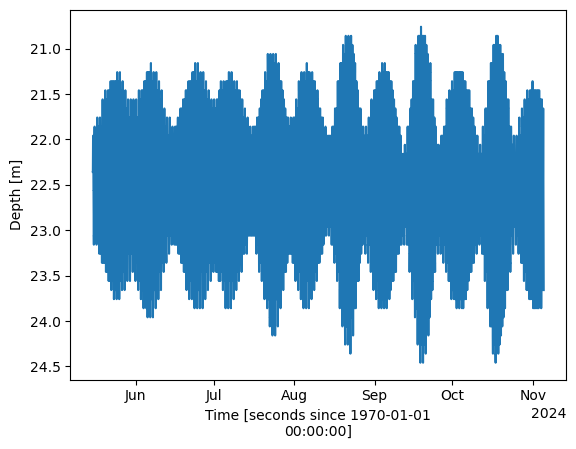

In [6]:
# 0 of range corresponds to transducers height, not seafloor

# original range start at 2.12
# for setup first cell range is 2.10, difference negligible 
print(f"Range values without tranducers height: {ds_1['range'].values}")

# add 1.4m tranducer height to range and depth
da_1 = api.clean.set_range_offset(ds_1, 1.40)

print(f"Range values with tranducers height added: {ds_1['range'].values}")

# Surface variation accounted for, depth varies
ds_1.depth.plot()
plt.gca().invert_yaxis()
plt.show()



### Controlling that values of pitch, roll and heading are ~constant

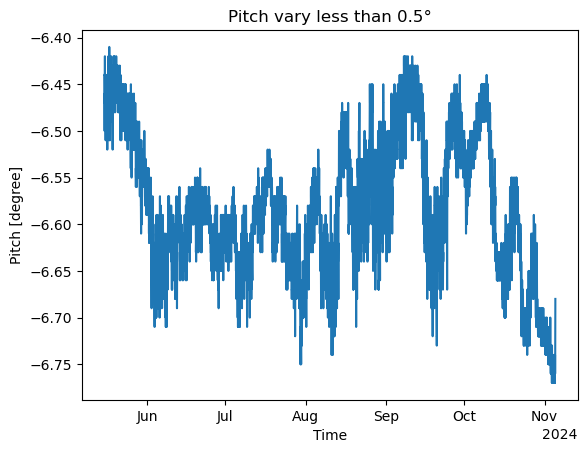

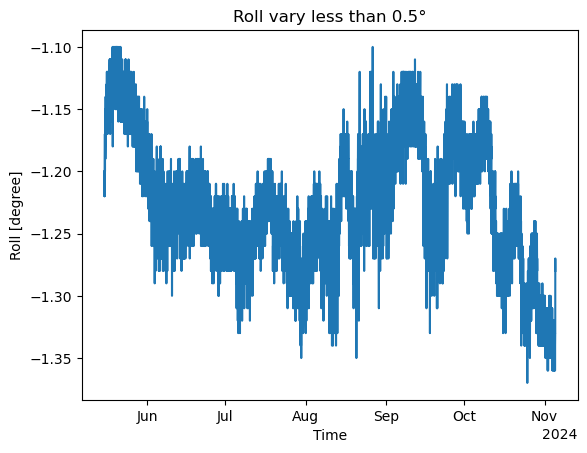

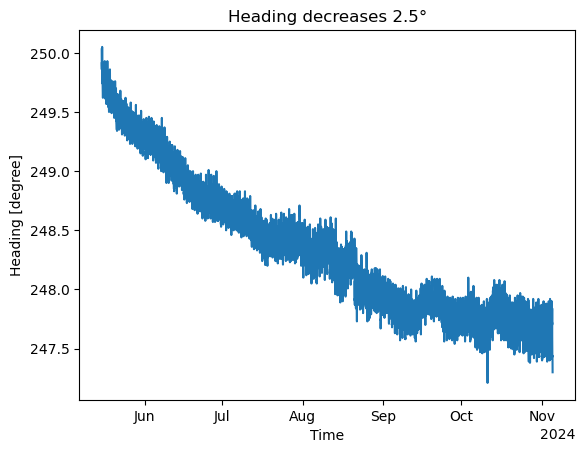

In [8]:
ds_1.pitch.plot()
plt.title('Pitch vary less than 0.5°')
plt.xlabel('Time')
plt.show()
ds_1['roll'].plot()
plt.title('Roll vary less than 0.5°')
plt.xlabel('Time')
plt.show()
ds_1.heading.plot()
plt.title('Heading decreases 2.5°')
plt.xlabel('Time')
plt.show()


###  Controlling coordinate system and setting declination

In [10]:
# Earth coordinate system is already used
print(f"Coordinate system: {ds_1.attrs['coord_sys']}")

# Declination low, can be neglied in this case
#dolfyn.set_declination(ds_1, -0.90) #I assumed lat=37N, long=8W, May 2024 which gave declination=0.9W.
#print(f"Declination: {ds_1.attrs.get('declination', 'Not set')}")

Coordinate system: earth


### Applying correlation filter

Correlation tells how reliable the signal in a bin is based on comparing it to the expected pattern. 


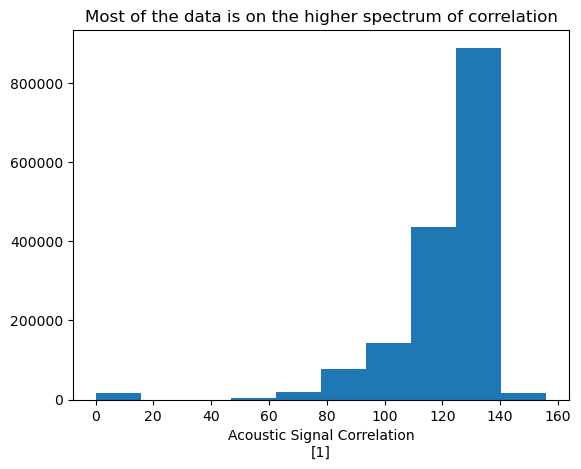

Data removed for vel: 69812 (4.41%)


In [7]:
ds_1.corr.plot()
plt.title('Most of the data is on the higher spectrum of correlation')
plt.show()

corr_thresh=64
ds_2 = api.clean.correlation_filter(ds_1, thresh=corr_thresh) 

my.print_data_removed(ds_1, ds_2, 'vel')

### Removing outliers from signal amplitude

The signal amplitude is strong in the beginning and then decreases. Along the beam, there should only be values lower than those in the beginning, otherwise there is interference from e.g. fish, diver etc.


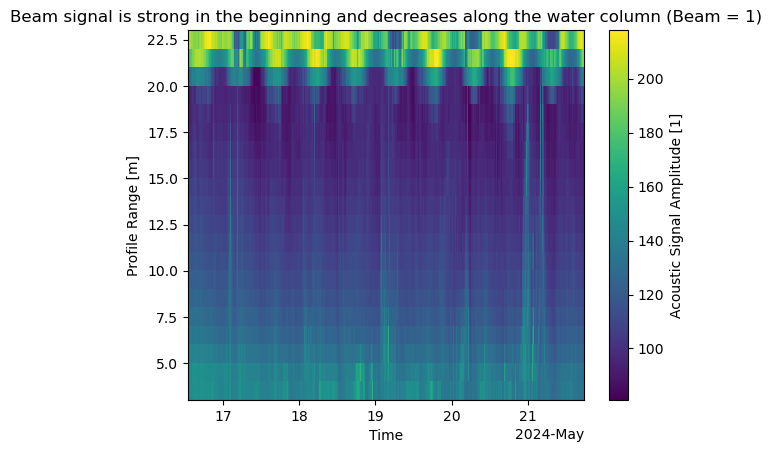

Max signals for each beam at the start [193, 190, 190, 203] 
Median signals for each beam at the end [90.0, 91.0, 89.0, 93.0] 
Data removed for vel: 180760 (11.94%)


In [8]:
ds_2.amp[0].isel(range=slice(0,20),time=slice(100,600)).plot()
plt.xlabel('Time')
plt.title('Beam signal is strong in the beginning and decreases along the water column (Beam = 1)')
plt.show()

# Finding max values of the signal in the beginning to decide bottom threshold
max_signals =[]
for i in(0,1,2,3):
     max_signals.append(ds_2.amp[i].sel(range=slice(2.12,4.12)).max().item())
print(f'Max signals for each beam at the start {max_signals} ')

# Finding median values of the signal in the end to decide surface threshold
median_signals =[]
for i in(0,1,2,3):
     median_signals.append(ds_2.amp[i].sel(range=slice(18,20)).median().item())
print(f'Median signals for each beam at the end {median_signals} ')

# Outliers are set to NaN assuming linear decay of signal, 
# and if less than 3 beams valid, velocity is set to Nan too.
ds_3 = my.detect_outliers(ds_2, bottom_threshold=225, surface_threshold=100) 
my.print_data_removed(ds_2, ds_3, 'vel')

<!-- ###  Saving data -->

### Saving data

In [9]:
dolfyn.save(ds_1, 'A0524000_raw.nc')        # raw dataset with minimal processing
dolfyn.save(ds_3, 'A0524000_processed.nc')  # processed dataset